In [ ]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 13.9 MB/s eta 0:00:00


EVALUASI ALGORITMA KLASIFIKASI (ANTI DATA LEAKAGE)
[INFO] Dataset berhasil digabung dengan Split Map. Total baris: 12555
[INFO] Distribusi Split Group:
split_group
TRAIN    10042
TEST      2513
--------------------------------------------------------------------------------

>>> Memproses Skenario 1 (Deteksi VPN)
    Jumlah Train: 10042 | Jumlah Test: 2513

>>> Memproses Skenario 2 (Kategori VPN)
    Jumlah Train: 2186 | Jumlah Test: 565

>>> Memproses Skenario 3 (Aplikasi VPN)
    Jumlah Train: 1919 | Jumlah Test: 492

[INFO] Gambar visualisasi berhasil disimpan di: /content/drive/MyDrive/1 Skripsi/skrip16feb/komparasi_algoritma_antibocor.png

TABEL RINGKASAN HASIL EVALUASI KOMPREHENSIF (Akurasi, Presisi, Recall, F1-Macro)
                            Accuracy                                                                    Precision                                                                       Recall                                                                     F1_Macr

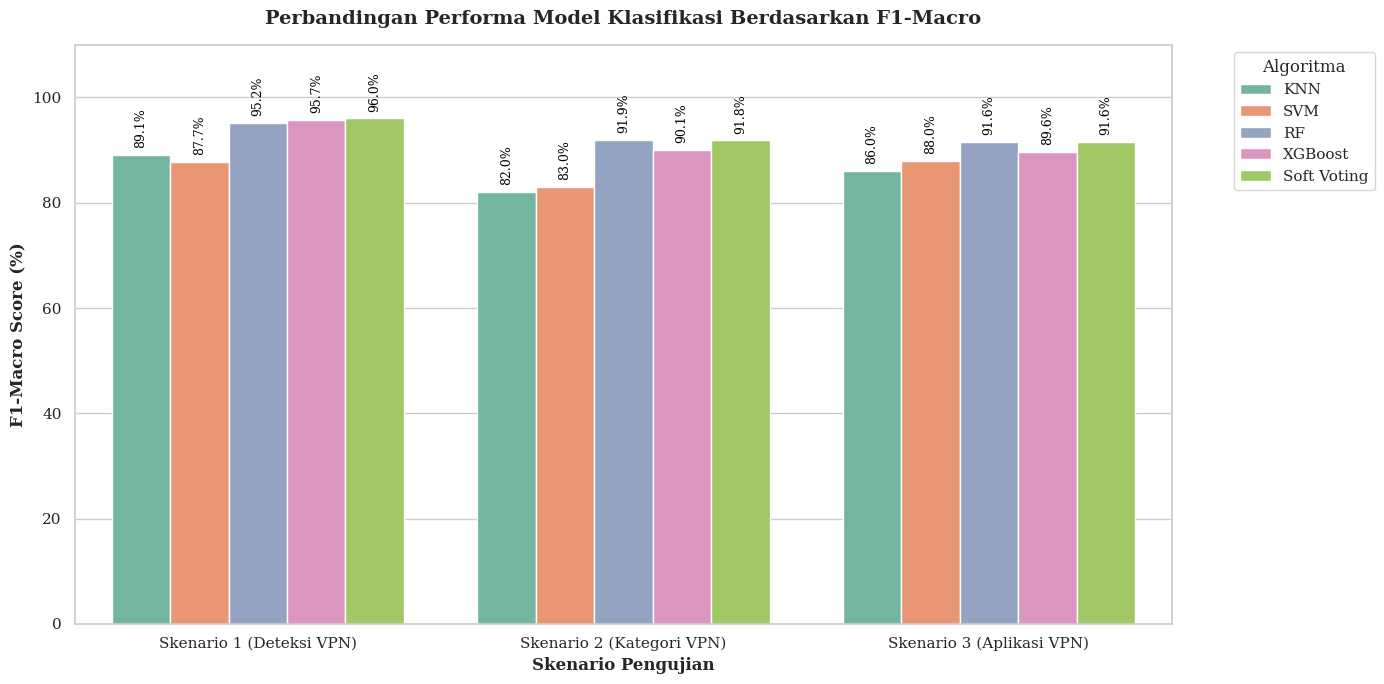

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# --- 1. KONFIGURASI TAMPILAN SKRIPSI ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

BASE_PATH = "/content/drive/MyDrive/1 Skripsi/skrip16feb"
FINAL_PESV_FILE = os.path.join(BASE_PATH, "HFV_dataset.csv")
SPLIT_MAP_FILE = os.path.join(BASE_PATH, "alpha_train_test_split_map.csv")

# 6 Aplikasi target (Berdasarkan threshold > 100 sampel VPN)
TARGET_APPS = ['Skype', 'BitTorrent', 'Hangout', 'Facebook', 'YouTube', 'Email']

print("="*80)
print("EVALUASI ALGORITMA KLASIFIKASI (ANTI DATA LEAKAGE)")
print("="*80)

# --- 2. PERSIAPAN DATA & PENCEGAHAN DATA LEAKAGE ---
# Load Dataset Utama
df = pd.read_csv(FINAL_PESV_FILE)
df = df.fillna(0)

# Load Split Map (Mencegah paket dari flow/PCAP yang sama terpisah ke train dan test)
split_map = pd.read_csv(SPLIT_MAP_FILE)

# Inner Join untuk menggabungkan dataset dengan label split-nya berdasarkan 'filename'
df = df.merge(split_map[['filename', 'split_group']], on='filename', how='inner')

print(f"[INFO] Dataset berhasil digabung dengan Split Map. Total baris: {len(df)}")
print("[INFO] Distribusi Split Group:")
print(df['split_group'].value_counts().to_string())
print("-" * 80)

# Pisahkan Metadata
metadata_cols = ['filename', 'application', 'category', 'binary_type', 'split_group']

# --- 3. DEFINISI MODEL ---
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier(n_jobs=-1)

# Ensemble Soft Voting
ensemble = VotingClassifier(
    estimators=[('RF', rf), ('XGB', xgb)],
    voting='soft',
    n_jobs=-1
)

models = {
    'KNN': knn,
    'SVM': svm,
    'RF': rf,
    'XGBoost': xgb,
    'Soft Voting': ensemble
}

results = []

# --- 4. FUNGSI EVALUASI UTAMA (MENGGUNAKAN SPLIT MAP) ---
def evaluate_scenario(df_scenario, target_col, scenario_name):
    # Filter Train dan Test secara ketat berdasarkan split_group dari Alpha
    df_train = df_scenario[df_scenario['split_group'].str.upper() == 'TRAIN'].copy()
    # Menggabungkan TEST (dan VAL jika ada) sebagai set pengujian akhir
    df_test = df_scenario[df_scenario['split_group'].str.upper().isin(['TEST', 'VAL', 'VALIDATION'])].copy()

    print(f"\n>>> Memproses {scenario_name}")
    print(f"    Jumlah Train: {len(df_train)} | Jumlah Test: {len(df_test)}")

    # Label Encoding
    le = LabelEncoder()
    # Fit pada seluruh target di skenario ini agar mapping konsisten
    le.fit(df_scenario[target_col])

    y_train = le.transform(df_train[target_col])
    y_test = le.transform(df_test[target_col])

    # Ekstraksi Fitur (X)
    X_train = df_train.drop(columns=[c for c in metadata_cols if c in df_train.columns])
    X_test = df_test.drop(columns=[c for c in metadata_cols if c in df_test.columns])

    # Standard Scaler (Fit DIBATASI HANYA PADA TRAIN untuk mencegah statistics leakage)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        # Latih Model
        model.fit(X_train_scaled, y_train)

        # Prediksi
        y_pred = model.predict(X_test_scaled)

        # Kalkulasi Metrik (Gunakan average='macro' karena data imbalanced)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        results.append({
            'Skenario': scenario_name,
            'Model': model_name,
            'Accuracy': acc * 100,
            'Precision': prec * 100,
            'Recall': rec * 100,
            'F1_Macro': f1 * 100
        })

# --- 5. EKSEKUSI 3 SKENARIO ---
# Skenario 1: Biner
evaluate_scenario(df, 'binary_type', 'Skenario 1 (Deteksi VPN)')

# Skenario 2: Kategori VPN
df_vpn = df[df['binary_type'] == 'VPN'].copy()
evaluate_scenario(df_vpn, 'category', 'Skenario 2 (Kategori VPN)')

# Skenario 3: Aplikasi Spesifik VPN (6 Aplikasi)
df_app = df_vpn[df_vpn['application'].isin(TARGET_APPS)].copy()
evaluate_scenario(df_app, 'application', 'Skenario 3 (Aplikasi VPN)')

# --- 6. VISUALISASI HASIL ---
df_results = pd.DataFrame(results)

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_results,
    x='Skenario',
    y='F1_Macro',
    hue='Model',
    palette='Set2'
)

plt.title('Perbandingan Performa Model Klasifikasi Berdasarkan F1-Macro', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Skenario Pengujian', fontsize=12, fontweight='bold')
plt.ylabel('F1-Macro Score (%)', fontsize=12, fontweight='bold')
plt.legend(title='Algoritma', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 110)

# Tambahkan angka di atas bar
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.annotate(f'{height:.1f}%',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom',
                     fontsize=9, color='black', xytext=(0, 5),
                     textcoords='offset points', rotation=90)

plt.tight_layout()
path_gambar = os.path.join(BASE_PATH, "komparasi_algoritma_antibocor.png")
plt.savefig(path_gambar, dpi=300)
print(f"\n[INFO] Gambar visualisasi berhasil disimpan di: {path_gambar}")

# Tampilkan Tabel Ringkasan (Menampilkan ke-4 Metrik)
print("\n" + "="*90)
print("TABEL RINGKASAN HASIL EVALUASI KOMPREHENSIF (Akurasi, Presisi, Recall, F1-Macro)")
print("="*90)

# Membuat pivot table yang rapi untuk ditampilkan
summary_table = df_results.pivot(index='Model', columns='Skenario', values=['Accuracy', 'Precision', 'Recall', 'F1_Macro'])
print(summary_table.round(2).to_string())

MEMULAI HYPERPARAMETER TUNING PADA 3 SKENARIO KLASIFIKASI

>>> MEMPROSES: Skenario 1 (Deteksi VPN)
--- Tuning Random Forest ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 10, 'criterion': 'entropy'}

--- Tuning XGBoost ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    Best Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.2}

--- Evaluasi Model Base (Default) vs Tuned ---
    F1-Macro Default : 95.9498%
    F1-Macro Tuned   : 95.9157%

>>> MEMPROSES: Skenario 2 (Kategori VPN)
--- Tuning Random Forest ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 30, 'criterion': 'gini'}

--- Tuning XGBoost ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    Best Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.2}


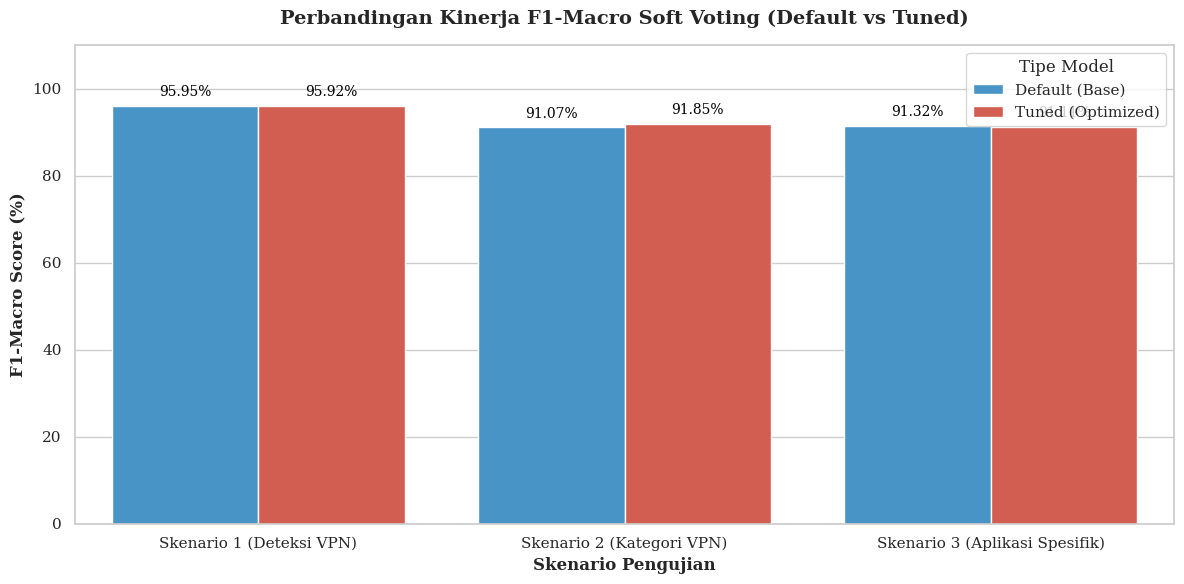

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# --- 1. KONFIGURASI TAMPILAN SKRIPSI ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

BASE_PATH = "/content/drive/MyDrive/1 Skripsi/skrip16feb"
FINAL_PESV_FILE = os.path.join(BASE_PATH, "HFV_dataset.csv")
SPLIT_MAP_FILE = os.path.join(BASE_PATH, "alpha_train_test_split_map.csv")
RANDOM_STATE = 42

TARGET_APPS = ['Skype', 'BitTorrent', 'Hangout', 'Facebook', 'YouTube', 'Email']

print("="*90)
print("MEMULAI HYPERPARAMETER TUNING PADA 3 SKENARIO KLASIFIKASI")
print("="*90)

# --- 2. PERSIAPAN DATA (ANTI-LEAKAGE) ---
df = pd.read_csv(FINAL_PESV_FILE).fillna(0)
split_map = pd.read_csv(SPLIT_MAP_FILE)
df = df.merge(split_map[['filename', 'split_group']], on='filename', how='inner')
metadata_cols = ['filename', 'application', 'category', 'binary_type', 'split_group']

# --- 3. DEFINISI MODEL & PARAMETER GRID (DENGAN PIPELINE) ---
HAS_XGB = True
MODEL_CONFIGS = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1),
        "params": {
            "classifier__n_estimators": [100, 200, 300],
            "classifier__max_depth": [None, 10, 20, 30],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__criterion": ["gini", "entropy"]
        }
    }
}

if HAS_XGB:
    MODEL_CONFIGS["XGBoost"] = {
        "model": XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss', use_label_encoder=False, n_jobs=-1),
        "params": {
            "classifier__n_estimators": [100, 200, 300],
            "classifier__learning_rate": [0.01, 0.1, 0.2],
            "classifier__max_depth": [3, 6, 10],
            "classifier__subsample": [0.8, 1.0]
        }
    }

# --- 4. FUNGSI TUNING DAN EVALUASI ---
tuning_results = []
best_params_record = {}

def tune_and_evaluate_scenario(df_scenario, target_col, scenario_name):
    print(f"\n{'='*60}")
    print(f">>> MEMPROSES: {scenario_name}")
    print(f"{'='*60}")

    # Split Train/Test
    df_train = df_scenario[df_scenario['split_group'].str.upper() == 'TRAIN'].copy()
    df_test = df_scenario[df_scenario['split_group'].str.upper().isin(['TEST', 'VAL', 'VALIDATION'])].copy()

    # Encode Target
    le = LabelEncoder()
    le.fit(df_scenario[target_col])
    y_train = le.transform(df_train[target_col])
    y_test = le.transform(df_test[target_col])

    X_train = df_train.drop(columns=[c for c in metadata_cols if c in df_train.columns])
    X_test = df_test.drop(columns=[c for c in metadata_cols if c in df_test.columns])

    best_estimators = {}
    best_params_record[scenario_name] = {}

    # 4A. Tuning Masing-Masing Model
    for model_name, config in MODEL_CONFIGS.items():
        print(f"--- Tuning {model_name} ---")
        # Buat Pipeline (Scaler -> Classifier)
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', config['model'])
        ])

        # RandomizedSearchCV
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=config['params'],
            n_iter=10,
            cv=3,
            scoring='f1_macro',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=1
        )
        search.fit(X_train, y_train)

        best_estimators[model_name] = search.best_estimator_
        # Simpan parameter terbaik untuk ditampilkan nanti (hapus prefix 'classifier__')
        clean_params = {k.replace('classifier__', ''): v for k, v in search.best_params_.items()}
        best_params_record[scenario_name][model_name] = clean_params
        print(f"    Best Params: {clean_params}\n")

    # 4B. Evaluasi Model DEFAULT (Soft Voting)
    print("--- Evaluasi Model Base (Default) vs Tuned ---")
    pipe_rf_base = Pipeline([('scaler', StandardScaler()), ('classifier', MODEL_CONFIGS["Random Forest"]["model"])])
    pipe_xgb_base = Pipeline([('scaler', StandardScaler()), ('classifier', MODEL_CONFIGS["XGBoost"]["model"])])

    voting_base = VotingClassifier(estimators=[('RF', pipe_rf_base), ('XGB', pipe_xgb_base)], voting='soft', n_jobs=-1)
    voting_base.fit(X_train, y_train)
    y_pred_base = voting_base.predict(X_test)
    f1_base = f1_score(y_test, y_pred_base, average='macro')

    # 4C. Evaluasi Model TUNED (Soft Voting)
    # Gunakan classifier yang sudah di-tuning dari pipeline
    clf_rf_tuned = best_estimators["Random Forest"].named_steps['classifier']
    clf_xgb_tuned = best_estimators["XGBoost"].named_steps['classifier']

    pipe_rf_tuned = Pipeline([('scaler', StandardScaler()), ('classifier', clf_rf_tuned)])
    pipe_xgb_tuned = Pipeline([('scaler', StandardScaler()), ('classifier', clf_xgb_tuned)])

    voting_tuned = VotingClassifier(estimators=[('RF', pipe_rf_tuned), ('XGB', pipe_xgb_tuned)], voting='soft', n_jobs=-1)
    voting_tuned.fit(X_train, y_train)
    y_pred_tuned = voting_tuned.predict(X_test)
    f1_tuned = f1_score(y_test, y_pred_tuned, average='macro')

    print(f"    F1-Macro Default : {f1_base*100:.4f}%")
    print(f"    F1-Macro Tuned   : {f1_tuned*100:.4f}%")

    tuning_results.append({
        'Skenario': scenario_name,
        'Default (Base)': f1_base * 100,
        'Tuned (Optimized)': f1_tuned * 100
    })

# --- 5. EKSEKUSI PADA 3 SKENARIO ---
# Skenario 1
tune_and_evaluate_scenario(df, 'binary_type', 'Skenario 1 (Deteksi VPN)')

# Skenario 2
df_vpn = df[df['binary_type'] == 'VPN'].copy()
tune_and_evaluate_scenario(df_vpn, 'category', 'Skenario 2 (Kategori VPN)')

# Skenario 3
df_app = df_vpn[df_vpn['application'].isin(TARGET_APPS)].copy()
tune_and_evaluate_scenario(df_app, 'application', 'Skenario 3 (Aplikasi Spesifik)')

# --- 6. VISUALISASI HASIL & TABEL ---
df_res = pd.DataFrame(tuning_results)
df_res_melt = df_res.melt(id_vars='Skenario', var_name='Tipe Model', value_name='F1_Macro')

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_res_melt, x='Skenario', y='F1_Macro', hue='Tipe Model', palette=['#3498db', '#e74c3c'])

plt.title('Perbandingan Kinerja F1-Macro Soft Voting (Default vs Tuned)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('F1-Macro Score (%)', fontsize=12, fontweight='bold')
plt.xlabel('Skenario Pengujian', fontsize=12, fontweight='bold')
plt.ylim(0, 110)

# Tambahkan angka di atas bar
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.annotate(f'{height:.2f}%',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom',
                     fontsize=10, color='black', xytext=(0, 5),
                     textcoords='offset points')

plt.tight_layout()
path_gambar = os.path.join(BASE_PATH, "hyperparameter_tuning_all.png")
plt.savefig(path_gambar, dpi=300)
print(f"\n[INFO] Gambar visualisasi disimpan di: {path_gambar}")

print("\n" + "="*90)
print("RINGKASAN PARAMETER TERBAIK PER SKENARIO")
print("="*90)
for sc, models in best_params_record.items():
    print(f"\n{sc}:")
    for m_name, params in models.items():
        print(f"  - {m_name}: {params}")

print("\n" + "="*90)
print("TABEL PENINGKATAN KINERJA (F1-MACRO %)")
print("="*90)
df_res['Selisih'] = df_res['Tuned (Optimized)'] - df_res['Default (Base)']
print(df_res.round(4).to_string(index=False))

MEMULAI ABLATION STUDY KOMPONEN HFV (ALPHA, BETA, GAMMA)
[INFO] Jumlah Fitur Alpha  : 128 dimensi
[INFO] Jumlah Fitur Beta   : 47 dimensi
[INFO] Jumlah Fitur Gamma  : 74 dimensi
------------------------------------------------------------------------------------------

>>> Memproses Skenario 1 (Deteksi VPN)
    [Alpha          ] F1: 88.26% | Acc: 91.80% | Prec: 88.21% | Rec: 88.30%
    [Beta           ] F1: 96.23% | Acc: 97.37% | Prec: 96.23% | Rec: 96.23%
    [Gamma          ] F1: 90.11% | Acc: 92.96% | Prec: 89.31% | Rec: 91.00%
    [Alpha + Beta   ] F1: 95.91% | Acc: 97.13% | Prec: 95.68% | Rec: 96.14%
    [Alpha + Gamma  ] F1: 91.47% | Acc: 94.03% | Prec: 91.32% | Rec: 91.63%
    [Beta + Gamma   ] F1: 95.80% | Acc: 97.10% | Prec: 96.19% | Rec: 95.42%
    [Full HFV       ] F1: 96.01% | Acc: 97.21% | Prec: 95.95% | Rec: 96.07%

>>> Memproses Skenario 2 (Kategori VPN)
    [Alpha          ] F1: 83.19% | Acc: 87.26% | Prec: 86.10% | Rec: 81.62%
    [Beta           ] F1: 92.25% | Acc: 93

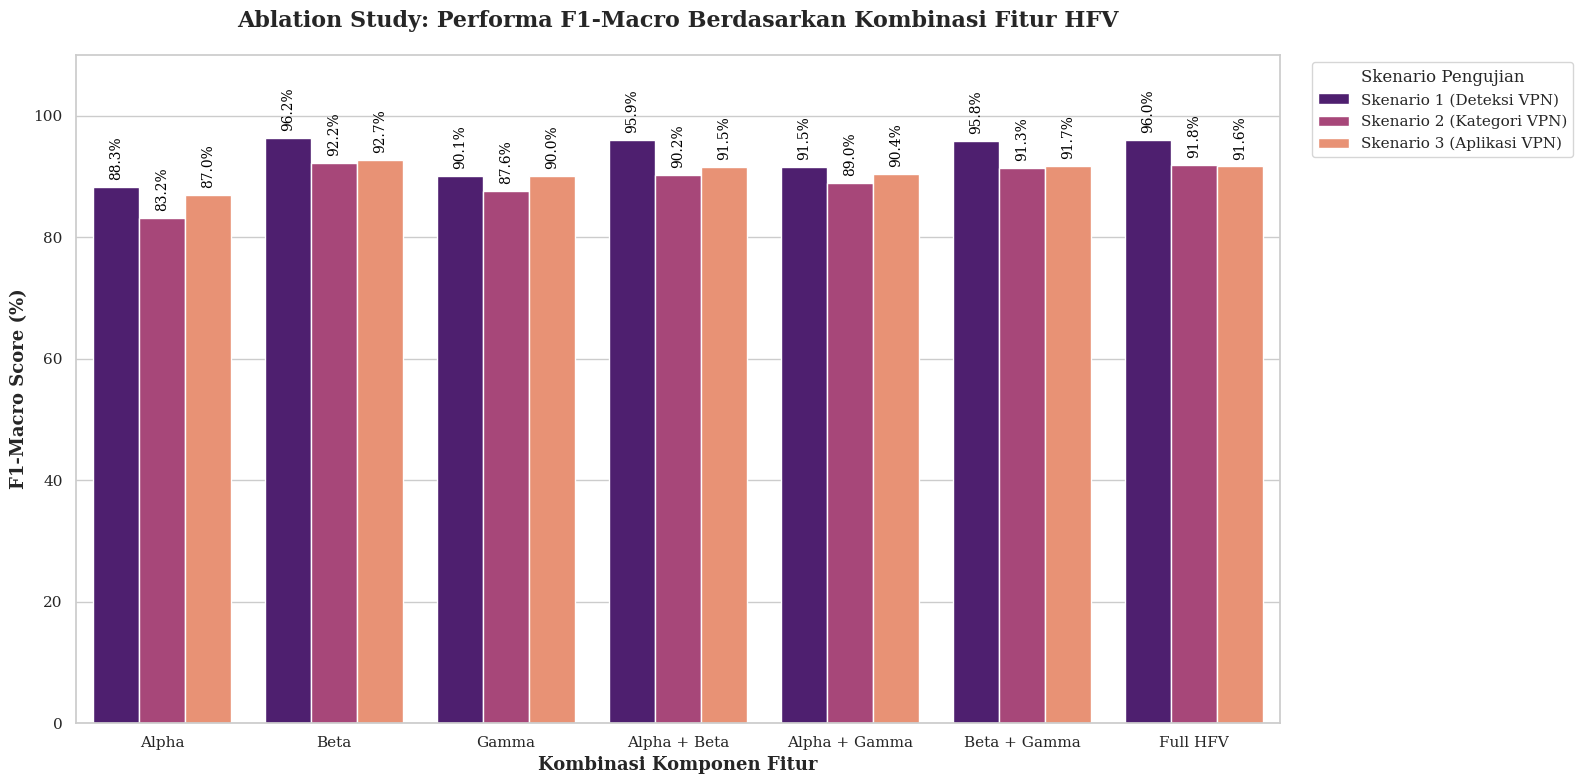

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

# --- 1. KONFIGURASI TAMPILAN SKRIPSI ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

BASE_PATH = "/content/drive/MyDrive/1 Skripsi/skrip16feb"
FINAL_PESV_FILE = os.path.join(BASE_PATH, "HFV_dataset.csv")
SPLIT_MAP_FILE = os.path.join(BASE_PATH, "alpha_train_test_split_map.csv")

TARGET_APPS = ['Skype', 'BitTorrent', 'Hangout', 'Facebook', 'YouTube', 'Email']

print("="*90)
print("MEMULAI ABLATION STUDY KOMPONEN HFV (ALPHA, BETA, GAMMA)")
print("="*90)

# --- 2. PERSIAPAN DATA & PENCEGAHAN DATA LEAKAGE ---
df = pd.read_csv(FINAL_PESV_FILE)
df = df.fillna(0)

split_map = pd.read_csv(SPLIT_MAP_FILE)
df = df.merge(split_map[['filename', 'split_group']], on='filename', how='inner')

metadata_cols = ['filename', 'application', 'category', 'binary_type', 'split_group']

# --- 3. IDENTIFIKASI FITUR ALPHA, BETA, GAMMA ---
# Alpha: Kolom yang mengandung 'alpha_pp_'
alpha_cols = [c for c in df.columns if 'alpha_pp_' in c]

# Gamma: Kolom statistik Burst
gamma_cols = [c for c in df.columns if 'burst' in c.lower()]

# Beta: Fitur statistik Flow (semua yang bukan alpha, bukan gamma, dan bukan metadata)
beta_cols = [c for c in df.columns if c not in alpha_cols and c not in gamma_cols and c not in metadata_cols]

print(f"[INFO] Jumlah Fitur Alpha  : {len(alpha_cols)} dimensi")
print(f"[INFO] Jumlah Fitur Beta   : {len(beta_cols)} dimensi")
print(f"[INFO] Jumlah Fitur Gamma  : {len(gamma_cols)} dimensi")
print("-" * 90)

# Definisi Kombinasi Fitur
feature_combinations = {
    'Alpha': alpha_cols,
    'Beta': beta_cols,
    'Gamma': gamma_cols,
    'Alpha + Beta': alpha_cols + beta_cols,
    'Alpha + Gamma': alpha_cols + gamma_cols,
    'Beta + Gamma': beta_cols + gamma_cols,
    'Full HFV': alpha_cols + beta_cols + gamma_cols
}

# --- 4. DEFINISI MODEL UTAMA ---
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)

soft_voting_base = VotingClassifier(
    estimators=[('RF', rf_base), ('XGB', xgb_base)],
    voting='soft',
    n_jobs=-1
)

results = []

# --- 5. FUNGSI ABLATION STUDY ---
def evaluate_ablation(df_scenario, target_col, scenario_name):
    print(f"\n>>> Memproses {scenario_name}")

    df_train = df_scenario[df_scenario['split_group'].str.upper() == 'TRAIN'].copy()
    df_test = df_scenario[df_scenario['split_group'].str.upper().isin(['TEST', 'VAL', 'VALIDATION'])].copy()

    le = LabelEncoder()
    le.fit(df_scenario[target_col])

    y_train = le.transform(df_train[target_col])
    y_test = le.transform(df_test[target_col])

    for combo_name, cols in feature_combinations.items():
        X_train = df_train[cols]
        X_test = df_test[cols]

        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Clone model agar bersih pada setiap iterasi
        model = clone(soft_voting_base)
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)

        print(f"    [{combo_name:<15}] F1: {f1*100:.2f}% | Acc: {acc*100:.2f}% | Prec: {prec*100:.2f}% | Rec: {rec*100:.2f}%")

        results.append({
            'Skenario': scenario_name,
            'Kombinasi Fitur': combo_name,
            'Accuracy': acc * 100,
            'F1_Macro': f1 * 100,
            'Precision': prec * 100,
            'Recall': rec * 100
        })

# --- 6. EKSEKUSI ---
evaluate_ablation(df, 'binary_type', 'Skenario 1 (Deteksi VPN)')

df_vpn = df[df['binary_type'] == 'VPN'].copy()
evaluate_ablation(df_vpn, 'category', 'Skenario 2 (Kategori VPN)')

df_app = df_vpn[df_vpn['application'].isin(TARGET_APPS)].copy()
evaluate_ablation(df_app, 'application', 'Skenario 3 (Aplikasi VPN)')

# --- 7. VISUALISASI HASIL ABLATION ---
df_results = pd.DataFrame(results)

# Urutan ideal untuk plot (Tunggal -> Ganda -> Penuh)
order_combo = ['Alpha', 'Beta', 'Gamma', 'Alpha + Beta', 'Alpha + Gamma', 'Beta + Gamma', 'Full HFV']

plt.figure(figsize=(16, 8))
ax = sns.barplot(
    data=df_results,
    x='Kombinasi Fitur',
    y='F1_Macro',
    hue='Skenario',
    order=order_combo,
    palette='magma' # Palet magma sangat elegan untuk transisi nilai
)

plt.title('Ablation Study: Performa F1-Macro Berdasarkan Kombinasi Fitur HFV', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Kombinasi Komponen Fitur', fontsize=13, fontweight='bold')
plt.ylabel('F1-Macro Score (%)', fontsize=13, fontweight='bold')
plt.legend(title='Skenario Pengujian', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='11')
plt.ylim(0, 110)

# Tambahkan angka di atas bar
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.annotate(f'{height:.1f}%',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom',
                     fontsize=10, color='black', xytext=(0, 5),
                     textcoords='offset points', rotation=90)

plt.tight_layout()
path_gambar = os.path.join(BASE_PATH, "ablation_study.png")
plt.savefig(path_gambar, dpi=300)
print(f"\n[INFO] Gambar visualisasi berhasil disimpan di: {path_gambar}")

# Tampilkan Tabel Ringkasan
print("\n" + "="*90)
print("TABEL RINGKASAN ABLATION STUDY (F1-MACRO, PRECISION, RECALL)")
print("="*90)
summary_table = df_results.pivot(index='Kombinasi Fitur', columns='Skenario', values=['F1_Macro', 'Precision', 'Recall']).reindex(order_combo)
print(summary_table.round(2).to_string())

MEMULAI ANALISIS KESALAHAN (CONFUSION MATRIX) - SKENARIO 2 & 3

>>> Memproses Skenario 2 (Kategori VPN)...

--- Laporan Klasifikasi untuk Skenario 2 (Kategori VPN) ---
               precision    recall  f1-score   support

         Chat     0.7419    0.7667    0.7541        30
        Email     0.9615    0.9615    0.9615        26
File Transfer     0.9202    0.9611    0.9402       180
          P2P     0.9688    0.9394    0.9538        66
    Streaming     0.9818    0.9153    0.9474        59
         VoIP     0.9602    0.9461    0.9531       204

     accuracy                         0.9381       565
    macro avg     0.9224    0.9150    0.9184       565
 weighted avg     0.9392    0.9381    0.9383       565

[INFO] Gambar disimpan di: /content/drive/MyDrive/1 Skripsi/skrip16feb/confusion_matrix_kategori.png

>>> Memproses Skenario 3 (Aplikasi Spesifik VPN)...

--- Laporan Klasifikasi untuk Skenario 3 (Aplikasi Spesifik VPN) ---
              precision    recall  f1-score   support



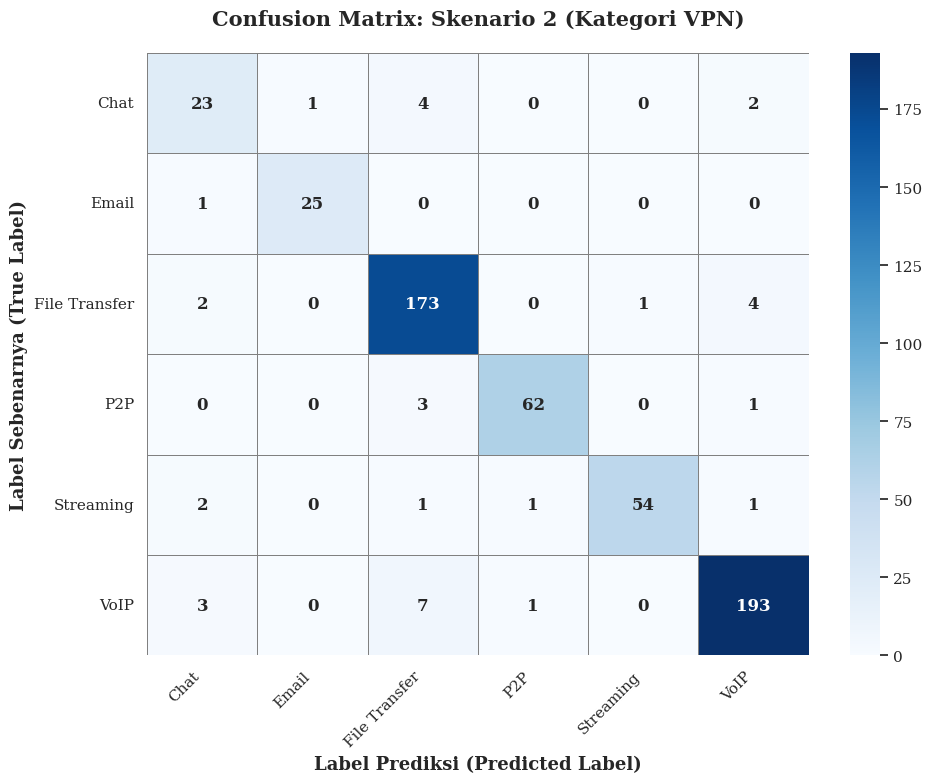

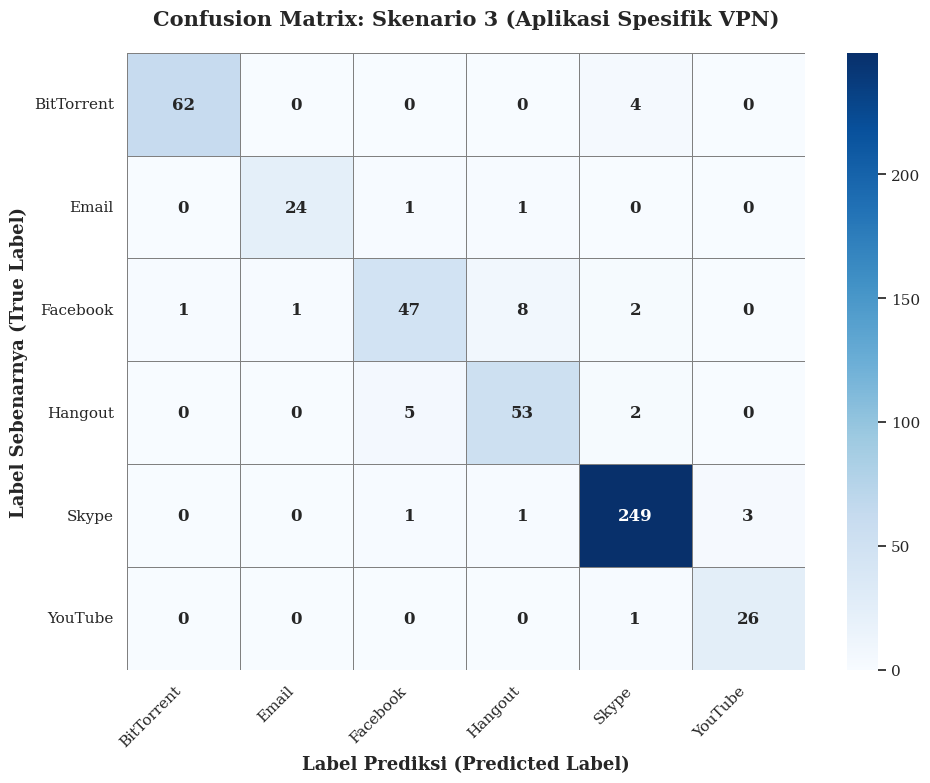

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# --- 1. KONFIGURASI TAMPILAN SKRIPSI ---
sns.set_theme(style="white") # Background putih bersih untuk matriks
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

BASE_PATH = "/content/drive/MyDrive/1 Skripsi/skrip16feb"
FINAL_PESV_FILE = os.path.join(BASE_PATH, "HFV_dataset.csv")
SPLIT_MAP_FILE = os.path.join(BASE_PATH, "alpha_train_test_split_map.csv")

TARGET_APPS = ['Skype', 'BitTorrent', 'Hangout', 'Facebook', 'YouTube', 'Email']

print("="*90)
print("MEMULAI ANALISIS KESALAHAN (CONFUSION MATRIX) - SKENARIO 2 & 3")
print("="*90)

# --- 2. PERSIAPAN DATA ---
df = pd.read_csv(FINAL_PESV_FILE)
df = df.fillna(0)
split_map = pd.read_csv(SPLIT_MAP_FILE)
df = df.merge(split_map[['filename', 'split_group']], on='filename', how='inner')
metadata_cols = ['filename', 'application', 'category', 'binary_type', 'split_group']

# --- 3. DEFINISI MODEL UTAMA (SOFT VOTING) ---
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)
ensemble = VotingClassifier(estimators=[('RF', rf), ('XGB', xgb)], voting='soft', n_jobs=-1)

# --- 4. FUNGSI GENERATE CONFUSION MATRIX ---
def generate_confusion_matrix(df_scenario, target_col, title, filename_suffix):
    print(f"\n>>> Memproses {title}...")

    df_train = df_scenario[df_scenario['split_group'].str.upper() == 'TRAIN'].copy()
    df_test = df_scenario[df_scenario['split_group'].str.upper().isin(['TEST', 'VAL', 'VALIDATION'])].copy()

    le = LabelEncoder()
    le.fit(df_scenario[target_col])

    y_train = le.transform(df_train[target_col])
    y_test = le.transform(df_test[target_col])

    class_names = le.classes_ # Ambil nama kelas asli

    X_train = df_train.drop(columns=[c for c in metadata_cols if c in df_train.columns])
    X_test = df_test.drop(columns=[c for c in metadata_cols if c in df_test.columns])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Latih model
    model = ensemble
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Cetak Classification Report
    print(f"\n--- Laporan Klasifikasi untuk {title} ---")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    # Buat Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Visualisasi Heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                     xticklabels=class_names, yticklabels=class_names,
                     annot_kws={"size": 12, "weight": "bold"},
                     linewidths=.5, linecolor='gray')

    plt.title(f'Confusion Matrix: {title}', fontsize=15, fontweight='bold', pad=20)
    plt.ylabel('Label Sebenarnya (True Label)', fontsize=13, fontweight='bold')
    plt.xlabel('Label Prediksi (Predicted Label)', fontsize=13, fontweight='bold')

    # Rotasi label agar rapi
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)

    plt.tight_layout()
    path_cm = os.path.join(BASE_PATH, f"confusion_matrix_{filename_suffix}.png")
    plt.savefig(path_cm, dpi=300)
    print(f"[INFO] Gambar disimpan di: {path_cm}")

# --- 5. EKSEKUSI ---
# Skenario 2: Kategori VPN
df_vpn = df[df['binary_type'] == 'VPN'].copy()
generate_confusion_matrix(df_vpn, 'category', 'Skenario 2 (Kategori VPN)', 'kategori')

# Skenario 3: Aplikasi VPN
df_app = df_vpn[df_vpn['application'].isin(TARGET_APPS)].copy()
generate_confusion_matrix(df_app, 'application', 'Skenario 3 (Aplikasi Spesifik VPN)', 'aplikasi')

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# --- 1. KONFIGURASI TAMPILAN SKRIPSI ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

BASE_PATH = "/content/drive/MyDrive/1 Skripsi/skrip16feb"
FINAL_PESV_FILE = os.path.join(BASE_PATH, "HFV_dataset.csv")
SPLIT_MAP_FILE = os.path.join(BASE_PATH, "alpha_train_test_split_map.csv")
TARGET_APPS = ['Skype', 'BitTorrent', 'Hangout', 'Facebook', 'YouTube', 'Email']

print("="*90)
print("MEMULAI ANALISIS KEPENTINGAN FITUR (FEATURE IMPORTANCE) - ALL 3 TASKS")
print("="*90)

# --- 2. PERSIAPAN DATA ---
df = pd.read_csv(FINAL_PESV_FILE).fillna(0)
split_map = pd.read_csv(SPLIT_MAP_FILE)
df = df.merge(split_map[['filename', 'split_group']], on='filename', how='inner')

# Helper untuk identifikasi komponen
def get_feature_component(feat_name):
    if 'alpha_pp_' in feat_name:
        return 'Alpha (DL/Payload)'
    elif 'burst' in feat_name.lower():
        return 'Gamma (Burst Stats)'
    else:
        return 'Beta (Flow Stats)'

# Warna Konsisten: Alpha=Merah, Beta=Biru, Gamma=Hijau
colors_pie = {'Alpha (DL/Payload)': '#e74c3c', 'Beta (Flow Stats)': '#3498db', 'Gamma (Burst Stats)': '#2ecc71'}
palette_bar = {'Alpha (DL/Payload)': '#e74c3c', 'Beta (Flow Stats)': '#3498db', 'Gamma (Burst Stats)': '#2ecc71'}

# --- 3. FUNGSI UTAMA ANALISIS ---
def analyze_feature_importance(df_subset, target_col, scenario_name, file_suffix):
    print(f"\n>>> Menganalisis: {scenario_name}...")

    # Filter hanya data TRAIN untuk analisis (Anti-Leakage)
    df_train = df_subset[df_subset['split_group'].str.upper() == 'TRAIN'].copy()

    metadata_cols = ['filename', 'application', 'category', 'binary_type', 'split_group']
    X_train = df_train.drop(columns=[c for c in metadata_cols if c in df_train.columns])
    y_train = LabelEncoder().fit_transform(df_train[target_col])
    feature_names = X_train.columns.tolist()

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Latih Model (RF & XGB)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)

    rf.fit(X_train_scaled, y_train)
    xgb.fit(X_train_scaled, y_train)

    # Rata-rata Importance
    rf_imp = rf.feature_importances_ / rf.feature_importances_.sum()
    xgb_imp = xgb.feature_importances_ / xgb.feature_importances_.sum()
    ensemble_imp = (rf_imp + xgb_imp) / 2

    # Buat DataFrame Hasil
    df_imp = pd.DataFrame({
        'Feature': feature_names,
        'Component': [get_feature_component(f) for f in feature_names],
        'Importance': ensemble_imp
    })

    # --- A. PIE CHART (Proporsi Komponen) ---
    df_comp = df_imp.groupby('Component')['Importance'].sum().reset_index()
    df_comp['Importance (%)'] = df_comp['Importance'] * 100

    print(f"--- Proporsi Komponen ({scenario_name}) ---")
    print(df_comp.to_string(index=False))

    plt.figure(figsize=(7, 7))
    # Pastikan urutan warna sesuai label yang muncul
    pie_colors = [colors_pie[c] for c in df_comp['Component']]

    plt.pie(df_comp['Importance'], labels=df_comp['Component'],
            autopct='%1.1f%%', startangle=140, colors=pie_colors,
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
            textprops={'fontsize': 11, 'fontweight': 'bold'})
    plt.title(f'Proporsi Fitur: {scenario_name}', fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, f"fi_pie_{file_suffix}.png"), dpi=300)
    plt.close() # Close agar tidak menumpuk di memori

    # --- B. BAR CHART (Top 20 Fitur) ---
    df_top20 = df_imp.sort_values(by='Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', hue='Component', data=df_top20,
                dodge=False, palette=palette_bar, edgecolor='black')

    plt.title(f'Top 20 Fitur: {scenario_name}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Tingkat Kepentingan (Importance Score)', fontsize=12, fontweight='bold')
    plt.ylabel(None)
    plt.legend(loc='lower right', fontsize='10')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, f"fi_bar_{file_suffix}.png"), dpi=300)
    plt.close()

    print(f"[INFO] Disimpan: fi_pie_{file_suffix}.png & fi_bar_{file_suffix}.png")

# --- 4. EKSEKUSI LOOP 3 SKENARIO ---

# Skenario 1: Biner (Full Dataset)
analyze_feature_importance(df, 'binary_type', 'Skenario 1 (Deteksi VPN)', 'biner')

# Skenario 2: Kategori (VPN Only)
df_vpn = df[df['binary_type'] == 'VPN'].copy()
analyze_feature_importance(df_vpn, 'category', 'Skenario 2 (Kategori VPN)', 'kategori')

# Skenario 3: Aplikasi (VPN Only + Target Apps)
df_app = df_vpn[df_vpn['application'].isin(TARGET_APPS)].copy()
analyze_feature_importance(df_app, 'application', 'Skenario 3 (Aplikasi Spesifik)', 'aplikasi')

MEMULAI ANALISIS KEPENTINGAN FITUR (FEATURE IMPORTANCE) - ALL 3 TASKS

>>> Menganalisis: Skenario 1 (Deteksi VPN)...
--- Proporsi Komponen (Skenario 1 (Deteksi VPN)) ---
          Component  Importance  Importance (%)
 Alpha (DL/Payload)    0.401651       40.165097
  Beta (Flow Stats)    0.366877       36.687748
Gamma (Burst Stats)    0.231472       23.147155
[INFO] Disimpan: fi_pie_biner.png & fi_bar_biner.png

>>> Menganalisis: Skenario 2 (Kategori VPN)...
--- Proporsi Komponen (Skenario 2 (Kategori VPN)) ---
          Component  Importance  Importance (%)
 Alpha (DL/Payload)    0.538590       53.858962
  Beta (Flow Stats)    0.207738       20.773783
Gamma (Burst Stats)    0.253673       25.367258
[INFO] Disimpan: fi_pie_kategori.png & fi_bar_kategori.png

>>> Menganalisis: Skenario 3 (Aplikasi Spesifik)...
--- Proporsi Komponen (Skenario 3 (Aplikasi Spesifik)) ---
          Component  Importance  Importance (%)
 Alpha (DL/Payload)    0.745683       74.568286
  Beta (Flow Stats)    0

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# --- 1. KONFIGURASI TAMPILAN ---
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.precision', 3)

BASE_PATH = "/content/drive/MyDrive/1 Skripsi/skrip16feb"
FINAL_PESV_FILE = os.path.join(BASE_PATH, "HFV_dataset.csv")
SPLIT_MAP_FILE = os.path.join(BASE_PATH, "alpha_train_test_split_map.csv")
TARGET_APPS = ['Skype', 'BitTorrent', 'Hangout', 'Facebook', 'YouTube', 'Email']

print("="*90)
print("MEMULAI ANALISIS KORELASI MULTIVARIAT (ALL 3 TASKS)")
print("="*90)

# --- 2. PERSIAPAN DATA ---
df = pd.read_csv(FINAL_PESV_FILE).fillna(0)
split_map = pd.read_csv(SPLIT_MAP_FILE)
df = df.merge(split_map[['filename', 'split_group']], on='filename', how='inner')

# Helper Komponen
def get_feature_component(feat_name):
    if 'alpha_pp_' in feat_name: return 'Alpha (DL)'
    elif 'burst' in feat_name.lower(): return 'Gamma (Burst)'
    else: return 'Beta (Flow)'

# --- 3. FUNGSI ANALISIS KORELASI ---
def analyze_correlation_task(df_subset, target_col, scenario_name, file_suffix):
    print(f"\n{'='*80}")
    print(f"PROSES: {scenario_name}")
    print(f"{'='*80}")

    # Filter Data Train
    df_train = df_subset[df_subset['split_group'].str.upper() == 'TRAIN'].copy()

    metadata_cols = ['filename', 'application', 'category', 'binary_type', 'split_group']
    X_train = df_train.drop(columns=[c for c in metadata_cols if c in df_train.columns])
    y_train = LabelEncoder().fit_transform(df_train[target_col])
    feature_names = X_train.columns.tolist()

    # --- A. HITUNG FEATURE IMPORTANCE (Untuk memilih Top 3) ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)

    rf.fit(X_train_scaled, y_train)
    xgb.fit(X_train_scaled, y_train)

    ensemble_imp = (rf.feature_importances_ + xgb.feature_importances_) / 2

    df_imp = pd.DataFrame({
        'Feature': feature_names,
        'Component': [get_feature_component(f) for f in feature_names],
        'Importance': ensemble_imp
    })

    # Pilih Top 3 dari masing-masing komponen
    top_alpha = df_imp[df_imp['Component'] == 'Alpha (DL)'].sort_values(by='Importance', ascending=False).head(3)['Feature'].tolist()
    top_beta = df_imp[df_imp['Component'] == 'Beta (Flow)'].sort_values(by='Importance', ascending=False).head(3)['Feature'].tolist()
    top_gamma = df_imp[df_imp['Component'] == 'Gamma (Burst)'].sort_values(by='Importance', ascending=False).head(3)['Feature'].tolist()

    top_9_features = top_alpha + top_beta + top_gamma

    print(f"[INFO] Top 3 Alpha : {top_alpha}")
    print(f"[INFO] Top 3 Beta  : {top_beta}")
    print(f"[INFO] Top 3 Gamma : {top_gamma}")

    # --- B. HITUNG MATRIKS KORELASI ---
    df_corr = X_train[top_9_features].copy()

    # Rename kolom agar lebih mudah dibaca (A/B/G)
    rename_map = {}
    for f in top_alpha: rename_map[f] = f"{f} (A)"
    for f in top_beta:  rename_map[f] = f"{f} (B)"
    for f in top_gamma: rename_map[f] = f"{f} (G)"

    df_corr_renamed = df_corr.rename(columns=rename_map)
    corr_matrix = df_corr_renamed.corr(method='spearman')

    # --- C. OUTPUT TEKS (COPY BAGIAN INI) ---
    print("\n>>> MATRIKS KORELASI (NUMERIK):")
    print(corr_matrix.to_string())

    print("\n>>> PASANGAN KORELASI TERTINGGI (REDUNDAN):")
    corr_pairs = corr_matrix.unstack().sort_values(kind="quicksort", ascending=False)
    corr_pairs = corr_pairs[corr_pairs != 1.0]
    unique_pairs = corr_pairs.iloc[::2]
    print(unique_pairs.head(5).to_string())

    print("\n>>> PASANGAN KORELASI TERENDAH (ORTOGONAL):")
    abs_pairs = unique_pairs.abs().sort_values()
    print(unique_pairs.loc[abs_pairs.index].head(5).to_string())

    # --- D. VISUALISASI ---
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
                vmin=-1, vmax=1, center=0, square=True, linewidths=.5,
                cbar_kws={"shrink": .8}, annot_kws={"size": 9, "weight": "bold"})

    plt.title(f'Korelasi Spearman Top Fitur: {scenario_name}', fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    path_corr = os.path.join(BASE_PATH, f"corr_matrix_{file_suffix}.png")
    plt.savefig(path_corr, dpi=300)
    print(f"\n[INFO] Gambar disimpan: {path_corr}")
    plt.close()

# --- 4. EKSEKUSI LOOP ---

# 1. Biner
analyze_correlation_task(df, 'binary_type', 'Skenario 1 (Deteksi VPN)', 'biner')

# 2. Kategori
df_vpn = df[df['binary_type'] == 'VPN'].copy()
analyze_correlation_task(df_vpn, 'category', 'Skenario 2 (Kategori VPN)', 'kategori')

# 3. Aplikasi
df_app = df_vpn[df_vpn['application'].isin(TARGET_APPS)].copy()
analyze_correlation_task(df_app, 'application', 'Skenario 3 (Aplikasi Spesifik)', 'aplikasi')

MEMULAI ANALISIS KORELASI MULTIVARIAT (ALL 3 TASKS)

PROSES: Skenario 1 (Deteksi VPN)
[INFO] Top 3 Alpha : ['alpha_pp_66', 'alpha_pp_119', 'alpha_pp_108']
[INFO] Top 3 Beta  : ['s2c_size_p25', 'flow_duration', 'c2s_size_p25']
[INFO] Top 3 Gamma : ['c2s_burst_pkts_mean', 'c2s_burst_dur_sum', 's2c_burst_dur_p25']

>>> MATRIKS KORELASI (NUMERIK):
                         alpha_pp_66 (A)  alpha_pp_119 (A)  alpha_pp_108 (A)  s2c_size_p25 (B)  flow_duration (B)  c2s_size_p25 (B)  c2s_burst_pkts_mean (G)  c2s_burst_dur_sum (G)  s2c_burst_dur_p25 (G)
alpha_pp_66 (A)                    1.000             0.844             0.536             0.257             -0.013             0.279                   -0.183                 -0.179                 -0.134
alpha_pp_119 (A)                   0.844             1.000             0.544             0.246             -0.026             0.279                   -0.128                 -0.137                 -0.091
alpha_pp_108 (A)                   0.536     

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- 1. KONFIGURASI TAMPILAN ---
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.precision', 3)

BASE_PATH = "/content/drive/MyDrive/1 Skripsi/skrip16feb"
FINAL_PESV_FILE = os.path.join(BASE_PATH, "HFV_dataset.csv")
SPLIT_MAP_FILE = os.path.join(BASE_PATH, "alpha_train_test_split_map.csv")
TARGET_APPS = ['Skype', 'BitTorrent', 'Hangout', 'Facebook', 'YouTube', 'Email']

print("="*90)
print("ANALISIS KORELASI MULTIVARIAT (HARDCODED CONSISTENCY)")
print("="*90)

# --- 2. DEFINISI FITUR TERBAIK (HARDCODED DARI HASIL SEBELUMNYA) ---
# Ini menjamin konsistensi mutlak dengan Bar Chart Feature Importance Anda

TOP_FEATURES = {
    'Skenario 1 (Deteksi VPN)': {
        'Alpha': ['alpha_pp_66', 'alpha_pp_119', 'alpha_pp_108'],
        'Beta':  ['s2c_size_p25', 'flow_duration', 'c2s_size_p25'],
        'Gamma': ['c2s_burst_pkts_mean', 'c2s_burst_dur_sum', 's2c_burst_dur_p25']
    },
    'Skenario 2 (Kategori VPN)': {
        'Alpha': ['alpha_pp_105', 'alpha_pp_84', 'alpha_pp_26'],
        'Beta':  ['s2c_size_skew', 's2c_iat_kurt', 'c2s_size_min'],
        'Gamma': ['c2s_burst_vol_min', 'c2s_burst_dur_max', 'c2s_burst_dur_std']
    },
    'Skenario 3 (Aplikasi Spesifik)': {
        'Alpha': ['alpha_pp_92', 'alpha_pp_84', 'alpha_pp_105'],
        # Beta & Gamma diambil dari hasil Feature Importance Skenario 3 sebelumnya
        'Beta':  ['c2s_size_max', 'flow_total_packets', 's2c_size_mean'],
        'Gamma': ['c2s_burst_vol_max', 's2c_burst_vol_mean', 'c2s_burst_dur_min']
    }
}

# --- 3. PERSIAPAN DATA ---
df = pd.read_csv(FINAL_PESV_FILE).fillna(0)
split_map = pd.read_csv(SPLIT_MAP_FILE)
df = df.merge(split_map[['filename', 'split_group']], on='filename', how='inner')

# --- 4. FUNGSI ANALISIS KORELASI ---
def analyze_correlation_hardcoded(df_subset, scenario_name, file_suffix):
    print(f"\n{'='*80}")
    print(f"PROSES: {scenario_name}")
    print(f"{'='*80}")

    # Ambil fitur target untuk skenario ini
    feats = TOP_FEATURES[scenario_name]
    top_9_features = feats['Alpha'] + feats['Beta'] + feats['Gamma']

    print(f"[INFO] Menggunakan Fitur Konsisten:")
    print(f"  > Alpha : {feats['Alpha']}")
    print(f"  > Beta  : {feats['Beta']}")
    print(f"  > Gamma : {feats['Gamma']}")

    # Filter Data Train
    df_train = df_subset[df_subset['split_group'].str.upper() == 'TRAIN'].copy()

    # Ambil Data X
    df_corr = df_train[top_9_features].copy()

    # Rename kolom agar lebih mudah dibaca (A/B/G)
    rename_map = {}
    for f in feats['Alpha']: rename_map[f] = f"{f} (A)"
    for f in feats['Beta']:  rename_map[f] = f"{f} (B)"
    for f in feats['Gamma']: rename_map[f] = f"{f} (G)"

    df_corr_renamed = df_corr.rename(columns=rename_map)

    # Hitung Matriks Korelasi (Spearman)
    corr_matrix = df_corr_renamed.corr(method='spearman')

    # --- OUTPUT TEKS (COPY BAGIAN INI) ---
    print("\n>>> MATRIKS KORELASI (NUMERIK):")
    print(corr_matrix.to_string())

    print("\n>>> PASANGAN KORELASI TERTINGGI (REDUNDAN > 0.7):")
    corr_pairs = corr_matrix.unstack().sort_values(kind="quicksort", ascending=False)
    corr_pairs = corr_pairs[corr_pairs != 1.0] # Hapus diagonal
    unique_pairs = corr_pairs.iloc[::2] # Hapus duplikat
    print(unique_pairs.head(5).to_string())

    print("\n>>> PASANGAN KORELASI TERENDAH (ORTOGONAL mendekati 0):")
    abs_pairs = unique_pairs.abs().sort_values()
    print(unique_pairs.loc[abs_pairs.index].head(5).to_string())

    # --- VISUALISASI ---
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
                vmin=-1, vmax=1, center=0, square=True, linewidths=.5,
                cbar_kws={"shrink": .8}, annot_kws={"size": 9, "weight": "bold"})

    plt.title(f'Korelasi Spearman Top Fitur: {scenario_name}', fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    path_corr = os.path.join(BASE_PATH, f"corr_matrix_hardcoded_{file_suffix}.png")
    plt.savefig(path_corr, dpi=300)
    print(f"\n[INFO] Gambar disimpan: {path_corr}")
    plt.close()

# --- 5. EKSEKUSI LOOP ---

# 1. Biner
analyze_correlation_hardcoded(df, 'Skenario 1 (Deteksi VPN)', 'biner')

# 2. Kategori
df_vpn = df[df['binary_type'] == 'VPN'].copy()
analyze_correlation_hardcoded(df_vpn, 'Skenario 2 (Kategori VPN)', 'kategori')

# 3. Aplikasi
df_app = df_vpn[df_vpn['application'].isin(TARGET_APPS)].copy()
analyze_correlation_hardcoded(df_app, 'Skenario 3 (Aplikasi Spesifik)', 'aplikasi')

ANALISIS KORELASI MULTIVARIAT (HARDCODED CONSISTENCY)

PROSES: Skenario 1 (Deteksi VPN)
[INFO] Menggunakan Fitur Konsisten:
  > Alpha : ['alpha_pp_66', 'alpha_pp_119', 'alpha_pp_108']
  > Beta  : ['s2c_size_p25', 'flow_duration', 'c2s_size_p25']
  > Gamma : ['c2s_burst_pkts_mean', 'c2s_burst_dur_sum', 's2c_burst_dur_p25']

>>> MATRIKS KORELASI (NUMERIK):
                         alpha_pp_66 (A)  alpha_pp_119 (A)  alpha_pp_108 (A)  s2c_size_p25 (B)  flow_duration (B)  c2s_size_p25 (B)  c2s_burst_pkts_mean (G)  c2s_burst_dur_sum (G)  s2c_burst_dur_p25 (G)
alpha_pp_66 (A)                    1.000             0.844             0.536             0.257             -0.013             0.279                   -0.183                 -0.179                 -0.134
alpha_pp_119 (A)                   0.844             1.000             0.544             0.246             -0.026             0.279                   -0.128                 -0.137                 -0.091
alpha_pp_108 (A)                  